# dJ/dV Curve Fitting

Fits the sigmoid + Gaussian-hump model (`djdv_model.py`) to each dJ/dV
curve and writes the six parameters, keyed by composition, to
`data/composition_djdV.csv`.

The input is the **faradaic** current, ½·(J_fwd + J_rev), built in
`preprocessing.ipynb`. Capacitive current is +C·ν on the forward sweep
and −C·ν on the reverse, so the average cancels it, and cancels the
reversible surface redox with it. This is the only target built from
both halves of the cycle; η, the Tafel slope and durability all stay on
the reverse sweep alone.

The curves are built from the **faradaic** current of the 5th cycle:
forward and reverse sweeps averaged at matched applied potential, which
cancels the ±C·ν charging term and keeps the anodic oxide-formation
peak that lives on the forward sweep.

Both terms of the model are physical. The sigmoid is the OER onset: with
J ∝ exp(η/β), β = b/ln10, and V = η + I·R, differentiating gives
dJ/dV = (J/β)/(1 + R·A·J/β), a sigmoid in V of steepness 1/β and plateau
1/(R·A). The Gaussian is the surface-oxidation peak, centred near
1.2–1.4 V and roughly 300 mV wide, so `u1` reads off where the oxide
forms and `A2` how much charge it carries.

Fitting is on V ≥ 1.05 V; below that the signal is baseline the model has
no terms for.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

from djdv_model import djdv_model, residuals
from oer_utils import (
    load_catalyst_summary,
    list_data_files,
    match_composition,
    composition_values,
)

DJDV_DIR = 'data/dJdV/'
GRAPH_DIR = 'images/djdVgraphs/'
OUTPUT_CSV = 'data/composition_djdV.csv'
SUMMARY_CSV = 'data/PtPdAuIr_summary.csv'

V_FIT_MIN = 1.05  # Fit window: OER onset region only.

# Oxidation-peak bounds. The peak sits between roughly 1.1 and 1.5 V and
# is broad, so s1 is allowed up to 0.30 V. Only 2 of 168 curves land on
# the u1 ceiling.
U1_MIN, U1_MAX = 1.05, 1.60
S1_MIN, S1_MAX = 0.02, 0.30

# Multistart seeds for the peak centre, spanning the window. The problem
# is nonconvex and a single start lets the Gaussian settle on ripples in
# the OER rise instead of the peak.
U1_SEED_GRID = np.linspace(U1_MIN + 0.03, U1_MAX - 0.03, 4)

## Fit routine

In [2]:
def fit_djdv(V, y):
    """Fit the sigmoid + hump model on the OER window.

    Multistart least squares. Amplitude bounds and starts scale with
    each curve's own maximum, the sigmoid midpoint starts at the
    half-maximum crossing, and the hump center is seeded from the local
    maximum inside the 1.05-1.35 V band plus a short grid.

    Returns ``(params, window_r2, V_window, y_window)``.
    """
    window = V >= V_FIT_MIN
    V_w, y_w = V[window], y[window]

    y_max = max(y_w.max(), 1e-9)
    above_half = V_w[y_w >= 0.5 * y_max]
    v_half = above_half.min() if len(above_half) else 1.6

    band = (V_w >= U1_MIN) & (V_w <= min(U1_MAX, 1.45))
    y_smooth = (
        pd.Series(y_w).rolling(9, center=True, min_periods=1).mean()
        .to_numpy()
    )
    u1_local = V_w[band][np.argmax(y_smooth[band])] if band.sum() > 3 else 1.2

    lb = np.array([0.5, 1.2, U1_MIN, S1_MIN, 0.0, 0.0])
    ub = np.array([60.0, 2.6, U1_MAX, S1_MAX, 3 * y_max, 1.5 * y_max])

    starts = []
    for u1 in [u1_local, *U1_SEED_GRID]:
        for s1 in (0.06, 0.15):
            starts.append([8.0, v_half, u1, s1, 1.2 * y_max, 0.3 * y_max])
            starts.append([20.0, v_half, u1, s1, y_max, 0.5 * y_max])
    starts.append(
        [4.0, min(2.4, v_half + 0.3), u1_local, 0.10,
         2.0 * y_max, 0.2 * y_max]
    )

    best = None
    for p0 in starts:
        p0 = np.clip(np.asarray(p0, dtype=float), lb + 1e-9, ub - 1e-9)
        result = least_squares(
            residuals, p0, bounds=(lb, ub), args=(V_w, y_w),
            jac='3-point', x_scale='jac', max_nfev=6000,
        )
        if best is None or result.cost < best.cost:
            best = result

    ss_res = float(np.sum((djdv_model(V_w, best.x) - y_w) ** 2))
    ss_tot = float(np.sum((y_w - y_w.mean()) ** 2))
    window_r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return best.x, window_r2, V_w, y_w

## Fit every curve

No curve is excluded. Every one of the 170 curves reaches a window R² of
at least 0.95.

In [3]:
catalyst_df = load_catalyst_summary(SUMMARY_CSV)
os.makedirs(GRAPH_DIR, exist_ok=True)
for stale in list_data_files(GRAPH_DIR):
    os.remove(os.path.join(GRAPH_DIR, stale))

PARAM_NAMES = ['k', 'V0', 'u1', 's1', 'A1', 'A2']
records = []

with open(OUTPUT_CSV, 'w') as out_file:
    out_file.write('Pt,Pd,Au,Ir,' + ','.join(PARAM_NAMES) + ',File\n')

    for filename in list_data_files(DJDV_DIR):
        cat_row = match_composition(catalyst_df, filename)
        Pt, Pd, Au, Ir = composition_values(cat_row)

        djdv_df = pd.read_csv(DJDV_DIR + filename)
        V = djdv_df['V'].to_numpy(dtype=float)
        y = djdv_df['dJdV'].to_numpy(dtype=float)
        finite = np.isfinite(V) & np.isfinite(y)
        V, y = V[finite], y[finite]

        p_fit, window_r2, V_w, y_w = fit_djdv(V, y)

        out_file.write(
            f'{Pt},{Pd},{Au},{Ir},'
            + ','.join(str(v) for v in p_fit)
            + f',{filename}\n'
        )
        records.append(
            dict(File=filename, r2=window_r2, **dict(zip(PARAM_NAMES, p_fit)))
        )

        fig, ax = plt.subplots(figsize=(6, 4))
        ax.plot(V_w, y_w, '.', ms=2.5, color='0.35', label='data')
        ax.plot(V_w, djdv_model(V_w, p_fit), color='crimson', lw=1.6,
                label='fit')
        ax.set_xlabel('$V$ vs Ref (V)')
        ax.set_ylabel('d$J$/d$V$ (A cm$^{-2}$ V$^{-1}$)')
        ax.set_title(f'{filename}  (window R² = {window_r2:.4f})',
                     fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(GRAPH_DIR, f'dJdV_{filename}.pdf'))
        plt.close(fig)

fits = pd.DataFrame(records)
print(f'curves fitted: {len(fits)}')
print(
    'window R²: median {:.4f} | min {:.4f} | p1 {:.4f} | '
    '>= 0.95: {}/{}'.format(
        fits['r2'].median(), fits['r2'].min(), fits['r2'].quantile(0.01),
        int((fits['r2'] >= 0.95).sum()), len(fits),
    )
)
print(f'u1 on its upper bound: {int((fits["u1"] >= U1_MAX - 1e-3).sum())}')
print('\nfitted parameters:')
print(fits[PARAM_NAMES].describe().T[['min', '50%', 'max', 'std']].round(4)
      .to_string())

curves fitted: 170
window R²: median 0.9987 | min 0.9365 | p1 0.9847 | >= 0.95: 169/170
u1 on its upper bound: 1

fitted parameters:
       min      50%      max     std
k   5.1726  11.3716  27.0598  2.1080
V0  1.3530   1.7103   1.9240  0.0643
u1  1.2068   1.3739   1.6000  0.0777
s1  0.0488   0.0953   0.3000  0.0349
A1  0.0140   0.0696   0.1767  0.0192
A2  0.0009   0.0105   0.0340  0.0078


## Fit quality

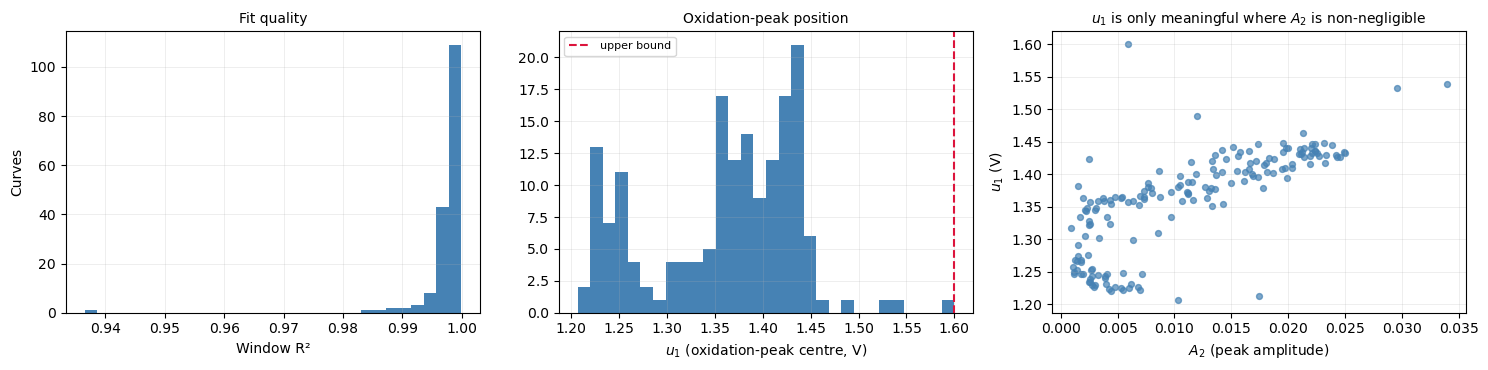

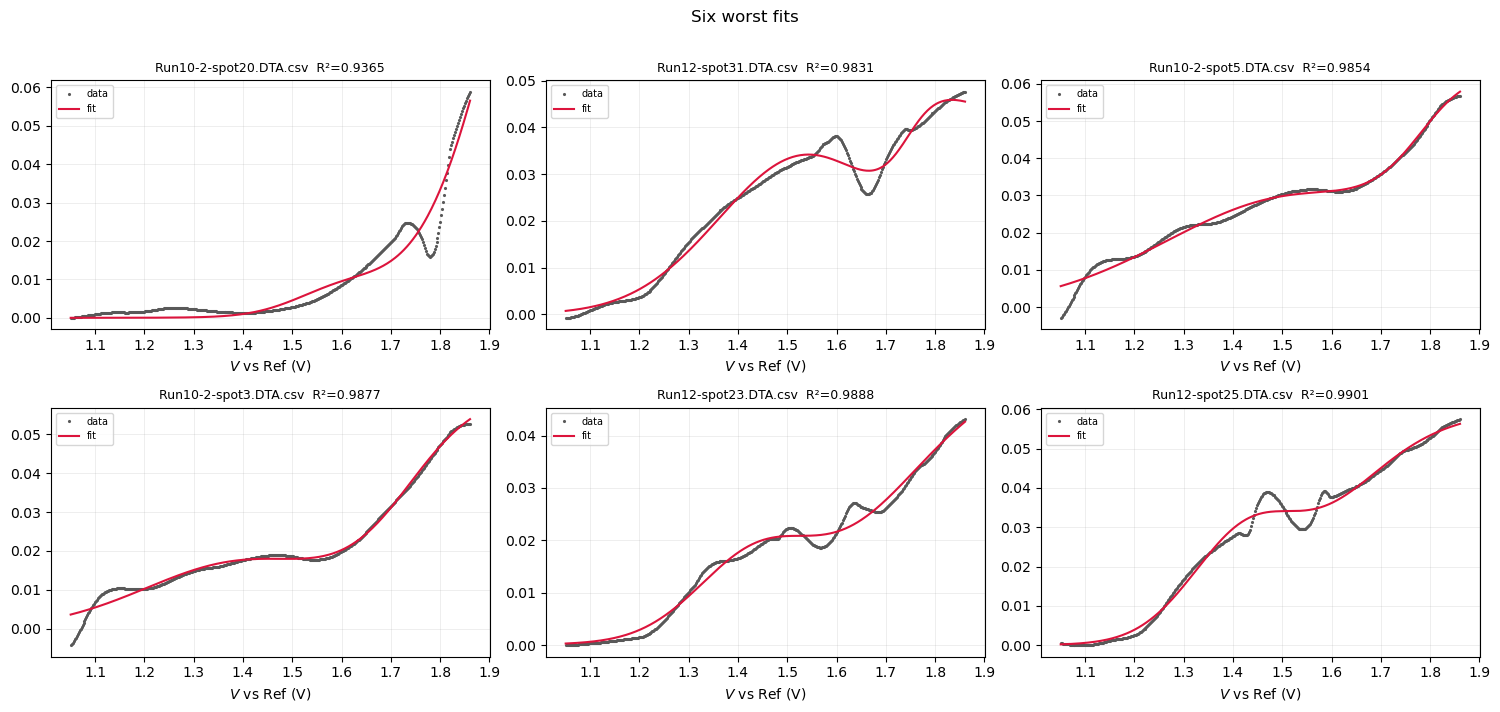

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))

axes[0].hist(fits['r2'], bins=30, color='steelblue')
axes[0].set_xlabel('Window R²')
axes[0].set_ylabel('Curves')
axes[0].set_title('Fit quality', fontsize=10)

axes[1].hist(fits['u1'], bins=30, color='steelblue')
axes[1].axvline(U1_MAX, color='crimson', ls='--', label='upper bound')
axes[1].set_xlabel('$u_1$ (oxidation-peak centre, V)')
axes[1].set_title('Oxidation-peak position', fontsize=10)
axes[1].legend(fontsize=8)

axes[2].scatter(fits['A2'], fits['u1'], s=18, alpha=0.7, color='steelblue')
axes[2].set_xlabel('$A_2$ (peak amplitude)')
axes[2].set_ylabel('$u_1$ (V)')
axes[2].set_title('$u_1$ is only meaningful where $A_2$ is non-negligible',
                  fontsize=10)

for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('images/djdv_fit_quality.png', dpi=200, bbox_inches='tight')
plt.show()

worst = fits.nsmallest(6, 'r2')
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (_, row) in zip(axes.ravel(), worst.iterrows()):
    dd = pd.read_csv(DJDV_DIR + row['File'])
    V = dd['V'].to_numpy(float)
    y = dd['dJdV'].to_numpy(float)
    w = V >= V_FIT_MIN
    p = row[PARAM_NAMES].to_numpy(float)
    ax.plot(V[w], y[w], '.', ms=2.5, color='0.35', label='data')
    ax.plot(V[w], djdv_model(V[w], p), color='crimson', lw=1.5, label='fit')
    ax.set_title(f'{row["File"][:24]}  R²={row["r2"]:.4f}', fontsize=9)
    ax.set_xlabel('$V$ vs Ref (V)')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
fig.suptitle('Six worst fits', y=1.01)
plt.tight_layout()
plt.savefig('images/djdv_worst_fits.png', dpi=200, bbox_inches='tight')
plt.show()